# 0.環境構築

In [3]:
%pip install -q seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs
import japanize_matplotlib
import seaborn as sns

%matplotlib inline

In [25]:
#-----------------------------------------------
#grapfvizの設定
#-----------------------------------------------

import os
import sys

# Graphvizの bin フォルダのパスを指定 (環境に合わせて変更してください)
graphviz_path = r"C:\Program Files\Graphviz\bin"

# PATHに一時的に追加
os.environ["PATH"] += os.pathsep + graphviz_path

# この後に graphviz や pydot を呼び出す
import graphviz

# 1.データ分布のベイズ推論

## 1-1. データ生成

In [5]:
dt = sns.load_dataset('iris')
dt.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [17]:
X = dt.query('species =="setosa"').sepal_length.values
X

array([5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.6, 5. , 4.4, 4.9, 5.4, 4.8, 4.8,
       4.3, 5.8, 5.7, 5.4, 5.1, 5.7, 5.1, 5.4, 5.1, 4.6, 5.1, 4.8, 5. ,
       5. , 5.2, 5.2, 4.7, 4.8, 5.4, 5.2, 5.5, 4.9, 5. , 5.5, 4.9, 4.4,
       5.1, 5. , 4.5, 4.4, 5. , 5.1, 4.8, 5.1, 4.6, 5.3, 5. ])

<Axes: ylabel='Count'>

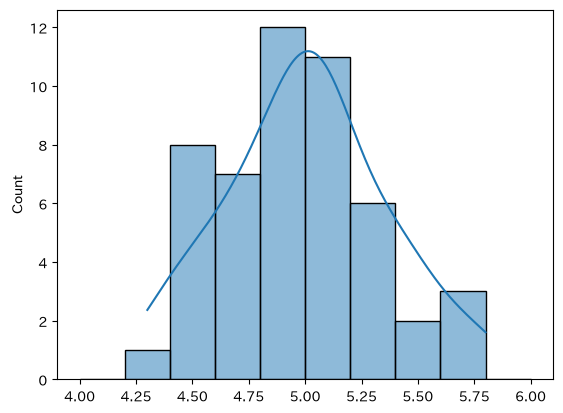

In [21]:
#-----------------------------------------------
#分布の確認
#-----------------------------------------------
bins = np.arange(4, 6.2, 0.2)
sns.histplot(X, kde=True, bins=bins)

## 1-2. 確率モデルの定義

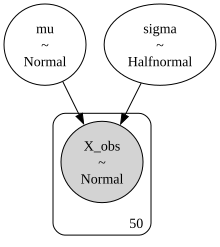

In [26]:
model11 = pm.Model()

with model11:
    mu = pm.Normal('mu', mu=0.0, sigma=10.0)
    sigma = pm.HalfNormal('sigma', sigma=10.0)
    X_obs = pm.Normal('X_obs', mu=mu, sigma=sigma, observed=X)
    
g = pm.model_to_graphviz(model11)
display(g)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


c:\Users\kzapp\python_training\bayes_python\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.
Sampling: [X_obs, mu, sigma]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,5.006,0.05,4.9,5.1,3718,2402,1.00,0.00082,0.00095
sigma,0.362,0.039,0.31,0.43,3436,2412,1.00,0.00066,0.00064


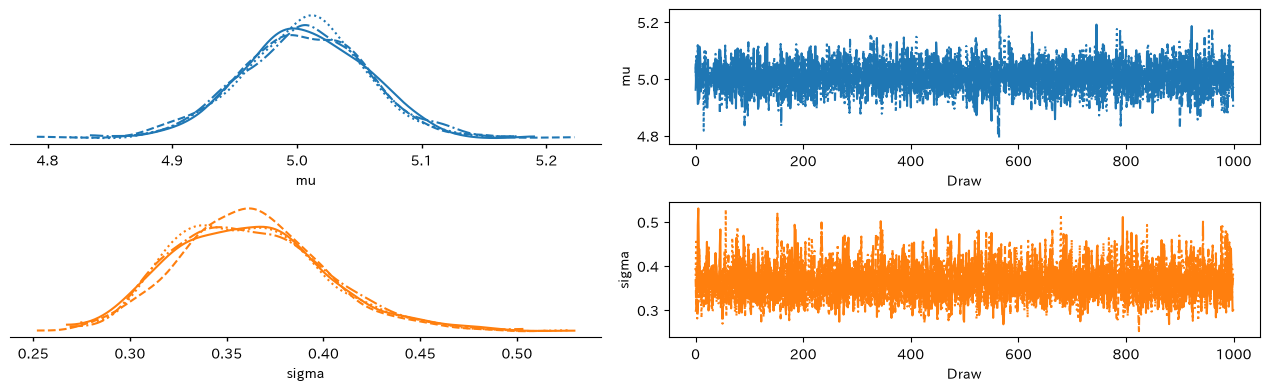

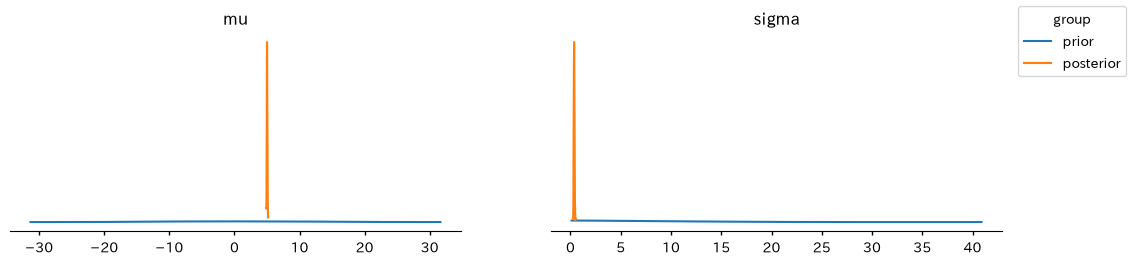

In [ ]:
#-----------------------------------------------
#MCMCの実行, trace確認
#-----------------------------------------------
with model11:
    idata1 = pm.sample(random_seed=42)
    idata1['prior'] = pm.sample_prior_predictive(random_seed=42).prior

#traca_plot
azp.plot_trace_dist(idata1)
plt.tight_layout();

#prior, posterior plot
azp.plot_prior_posterior(idata1)

#summary
summary = azs.summary(idata1)
display(summary)